<cell_type>markdown</cell_type># Compare WCSim simulation vs. real WCTE data — decay-in-flight vs not

Template notebook comparing the flattened simulation (`flatten_wcsim.C` output) against
merged real WCTE data (`WCTE_merged_production_R*.root`), for a **configurable particle
species** (`PARTICLE` in the config cell below - currently `"muon"` and `"pion"` are
defined; add more to `PARTICLE_PDG` / `make_beam_selection()` as needed).

Because the simulation flattening was updated to mirror the real data schema
(`hit_pmt_charges`, `hit_pmt_calibrated_times`, `hit_mpmt_slot_ids`, `hit_pmt_position_ids`,
WCTE-frame positions, ...), most of the code below is written generically and works
on **either** file with the same branch names.

Sections:
1. Load the simulation and list all interaction modes
1b. Select `PARTICLE` in the MC and split into **decay-in-flight** vs **not**
2. Load data and select `PARTICLE` the standard way (`analysis_tools.DataLoader` + `BeamSelection`)
3. Apply the same `good_wcte_pmts` channel mask to all samples
4. Basic comparison: data vs MC decay-in-flight vs MC non-decay (hits, charge, time)
5. Per-event truth summary table for the simulated `PARTICLE` sample
6. Decay-in-flight kinematics (decay path length, position, daughter KE)
7. Side-by-side event display (data event vs simulated decay-in-flight event, hits colored by parent track)


## 0. Imports & configuration

In [1]:
import sys
import numpy as np
import awkward as ak
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from analysis_tools import DataLoader, BeamSelection, print_cherenkov_thresholds

# --- particle selection: change this one line to switch species everywhere below ---
# Selected identically in the MC (by |true_pdg|) and in data (by the standard
# BeamSelection ACT/TOF cuts for this species) - see the PARTICLE_PDG /
# make_beam_selection cell right below for how each species is defined.
PARTICLE = "muon"   # "muon" | "pion"

# --- file paths: edit these for your own comparison ---
# WCSim flattened simulation (flatten_wcsim.C output) - pick the file matching PARTICLE
# SIM_FILE = "/eos/user/a/acraplet/WCSim/data/wcsim_wCDS_pi-_Beam_293MeV_5cm_0000_flat.root"
#SIM_FILE = "/eos/user/a/acraplet/WCSim/data/wcsim_wCDS_mu-_Beam_318MeV_5cm_0000_MDT_flat.root"
# SIM_FILE = "/eos/user/a/acraplet/WCSim/data/wcsim_wCDS_pi-_Beam_293MeV_5cm_0000_MDT_flat.root"
#SIM_FILE = "/eos/experiment/wcte/user_data/acraplet/forMarie/WCSimWorkshopData/mu-/mu-_410MeVc_flat.root"
#SIM_FILE = "/eos/user/m/mprincov/WCSim/WCSim_Princ_muon_scatter/build/flat_mu-_350MeV_30cm_0000.root"
SIM_FILE = "/eos/user/m/mprincov/WCSim/WCSim_Princ_muon_scatter/build/Aug2026/flat_mu-_350MeV_30cm_0000_MDT.root"
# SIM_FILE = "/eos/user/a/acraplet/WCSim/data/wcsim_wCDS_pi-_Beam_293MeV_5cm_0000_flat.root"

DATA_FILE = "/eos/experiment/wcte/data/2025_commissioning/processed_offline_data/production_v1_1/1490/WCTE_merged_production_R1490.root"
# DATA_FILE = "/eos/user/a/acraplet/WCSim/Analysis/data/WCTE_merged_production_R1419.root"

# WCTE_event_display (https://github.com/cookl/WCTE_event_display) - standalone repo,
# not part of the analysis_tools package, so it needs to be added to sys.path by hand.
EVENT_DISPLAY_DIR = "/eos/user/m/mprincov/WCTE_event_display"

# stop collecting data-side events of the selected species once we have this many -
# the real data file has ~10^5 windows and a ~1 GB waveform branch we don't need here;
# raise this (or remove the early-stop below) once you've adapted the notebook further
N_DATA_EVENTS = 2000


In [2]:
# --- standard per-species definitions, keyed by PARTICLE. Add more rows here
#     (proton, kaon, electron, ...) as needed. ---
# PARTICLE_PDG: |true_pdg| of the MC primary for this species.
PARTICLE_PDG = {"muon": 13, "pion": 211}

# DECAY_DAUGHTER_PDG: |pdg| of the expected decay-in-flight daughter, used in
# section 6's decay-in-flight kinematics (pi- -> mu- nu_mu_bar, mu- -> e- nu nubar).
DECAY_DAUGHTER_PDG = {"pion": 13, "muon": 11}

def make_beam_selection(particle, eveto_cut, tagger_cut, tof_cut):
    """Standard ACT/TOF PID cuts for `particle`, per BeamSelection.selection's docstring:
    muons sit below threshold upstream (act_eveto) and above threshold downstream
    (act_tagger); pions sit below threshold in BOTH ACTs. Both are additionally
    required to be fast (TOF below the fast/slow separation).
    """
    if particle == "muon":
        cuts = [["act_eveto", "<", eveto_cut], ["act_tagger", ">", tagger_cut]]
    elif particle == "pion":
        cuts = [["act_eveto", "<", eveto_cut], ["act_tagger", "<", tagger_cut]]
    else:
        raise ValueError(f"no standard BeamSelection cuts defined for particle={particle!r} "
                          f"- add one to make_beam_selection()")
    cuts.append(["tof", "<", tof_cut])
    return BeamSelection.selection(particle, *cuts)

print(f"PARTICLE = {PARTICLE!r}  (MC selects |true_pdg| == {PARTICLE_PDG[PARTICLE]})")


PARTICLE = 'muon'  (MC selects |true_pdg| == 13)


## 1. Load the simulation

In [3]:
sim_branches = [
    # per-hit
    "hit_pmt_charges", "hit_pmt_calibrated_times", "hit_mpmt_slot_ids", "hit_pmt_position_ids",
    "hit_track_id", "hit_x", "hit_y", "hit_z",
    # per-event truth
    "n_digihits", "event_number", "true_pdg", "true_E", "true_ke",
    "true_vtx_x", "true_vtx_y", "true_vtx_z", "true_start_x", "true_start_y", "true_start_z",
    "true_stop_x", "true_stop_y", "true_stop_z",
    "stop_process", "had_inelastic", "had_elastic", "n_prim_daughters",
    "true_exit_ke", "true_stopvol", "n_elastic", "n_inelastic",
    # per-track (jagged, one entry per saved track in the event)
    "track_id", "track_parent_id", "track_pdg", "track_process", "track_ke",
    "track_start_x", "track_start_y", "track_start_z",
    "track_end_x", "track_end_y", "track_end_z", "track_nhits"
]

with uproot.open(SIM_FILE) as f:
    sim = f["hits"].arrays(sim_branches, library="ak")

print(f"Loaded {len(sim)} simulated events from {SIM_FILE}")


Loaded 1000 simulated events from /eos/user/m/mprincov/WCSim/WCSim_Princ_muon_scatter/build/Aug2026/flat_mu-_350MeV_30cm_0000_MDT.root



First 10 events - true_vtx vs true_start [cm]:
 evt      vtx_x      vtx_y      vtx_z    start_x    start_y    start_z
   0      0.000     -0.000   -123.796      0.000     -0.000   -123.796
   1      0.000     -0.000   -123.796      0.000     -0.000   -123.796
   2      0.000     -0.000   -123.796      0.000     -0.000   -123.796
   3      0.000     -0.000   -123.796      0.000     -0.000   -123.796
   4      0.000     -0.000   -123.796      0.000     -0.000   -123.796
   5      0.000     -0.000   -123.796      0.000     -0.000   -123.796
   6      0.000     -0.000   -123.796      0.000     -0.000   -123.796
   7      0.000     -0.000   -123.796      0.000     -0.000   -123.796
   8      0.000     -0.000   -123.796      0.000     -0.000   -123.796
   9      0.000     -0.000   -123.796      0.000     -0.000   -123.796
true_start - true_vtx over 1000 events:
  dx: mean +0.0000 cm, std 0.0000 cm
  dy: mean +0.0000 cm, std 0.0000 cm
  dz: mean +0.0000 cm, std 0.0000 cm
  |start - vtx|: mea

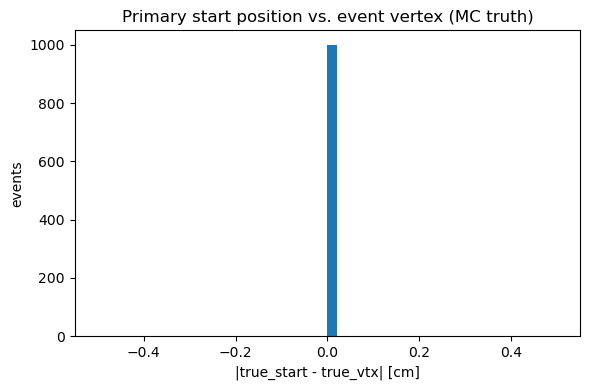

In [4]:
# --- sanity check: true_vtx_* (event vertex) vs true_start_* (primary track start) ---
# true_vtx_* comes from trig->GetVtx() (the event's generated interaction vertex),
# true_start_* from the primary track's own GetStart(). For a normal beam primary
# these should coincide; a systematic offset or outliers would flag either primaries
# not generated at the nominal vertex, or a mismatch in flatten_wcsim.C's primary-finding.

dvx = ak.to_numpy(sim["true_start_x"]) - ak.to_numpy(sim["true_vtx_x"])
dvy = ak.to_numpy(sim["true_start_y"]) - ak.to_numpy(sim["true_vtx_y"])
dvz = ak.to_numpy(sim["true_start_z"]) - ak.to_numpy(sim["true_vtx_z"])
dist = np.sqrt(dvx**2 + dvy**2 + dvz**2)

n_show = 10
print(f"\nFirst {n_show} events - true_vtx vs true_start [cm]:")
print(f"{'evt':>4} {'vtx_x':>10} {'vtx_y':>10} {'vtx_z':>10} {'start_x':>10} {'start_y':>10} {'start_z':>10}")
for i in range(min(n_show, len(sim))):
    print(f"{i:4d} {sim['true_vtx_x'][i]:10.3f} {sim['true_vtx_y'][i]:10.3f} {sim['true_vtx_z'][i]:10.3f} "
          f"{sim['true_start_x'][i]:10.3f} {sim['true_start_y'][i]:10.3f} {sim['true_start_z'][i]:10.3f}")

print(f"true_start - true_vtx over {len(sim)} events:")
print(f"  dx: mean {dvx.mean():+.4f} cm, std {dvx.std():.4f} cm")
print(f"  dy: mean {dvy.mean():+.4f} cm, std {dvy.std():.4f} cm")
print(f"  dz: mean {dvz.mean():+.4f} cm, std {dvz.std():.4f} cm")
print(f"  |start - vtx|: mean {dist.mean():.4f} cm, max {dist.max():.4f} cm")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(dist, bins=50)
ax.set_xlabel("|true_start - true_vtx| [cm]")
ax.set_ylabel("events")
ax.set_title("Primary start position vs. event vertex (MC truth)")
fig.tight_layout()


In [5]:
# --- all interaction modes in the simulated sample ---------------------------------
# flatten_wcsim.C records the primary's fate in `stop_process` (the discrete process
# at its stop point: "" = ranged out / ionization only) and every Geant4 creator
# process of every saved track in `track_process`. Print both.
from collections import Counter

n_ev = len(sim)

# 1. primary-particle stop process (one per event)
stop_counts = Counter(ak.to_list(sim["stop_process"]))
print(f"Primary stop_process over {n_ev} events:")
for proc, n in stop_counts.most_common():
    label = proc if proc else "(ranged out / ionization only)"
    print(f"  {label:<28s} {n:6d}  ({100*n/n_ev:5.1f}%)")

# 2. hadronic-interaction flags (elastic / inelastic anywhere along the primary lineage)
print("\nPrimary hadronic-interaction summary:")
print(f"  had_elastic == 1   : {int(ak.sum(sim['had_elastic'] == 1)):6d}")
print(f"  had_inelastic == 1 : {int(ak.sum(sim['had_inelastic'] == 1)):6d}")
print(f"  n_elastic distribution   : {dict(Counter(ak.to_list(sim['n_elastic'])))}")
print(f"  n_inelastic distribution : {dict(Counter(ak.to_list(sim['n_inelastic'])))}")

# 3. every creator process seen among all saved tracks in the sample
proc_counts = Counter(
    proc for ev in ak.to_list(sim["track_process"]) for proc in ev
)
print(f"\nAll track creator processes (across every saved track, {sum(proc_counts.values())} tracks):")
for proc, n in proc_counts.most_common():
    print(f"  {proc:<28s} {n:8d}")


Primary stop_process over 1000 events:
  muMinusCaptureAtRest            998  ( 99.8%)
  Decay                             2  (  0.2%)

Primary hadronic-interaction summary:
  had_elastic == 1   :      0
  had_inelastic == 1 :      0
  n_elastic distribution   : {0: 1000}
  n_inelastic distribution : {0: 1000}



All track creator processes (across every saved track, 115752 tracks):
  compt                           47777
  muIoni                          33640
  phot                            20837
  muMinusCaptureAtRest             5841
  eIoni                            4471
  initial                          1000
  eBrem                             828
  hadElastic                        625
  nCapture                          382
  conv                              234
  RadioactiveDecay                   66
  neutronInelastic                   29
  annihil                            13
  Decay                               6
  photonNuclear                       3


In [6]:
# --- select PARTICLE in the MC and split by decay-in-flight vs not ----------------
# "Decay in flight" = the primary's discrete fate at its stop point is a Geant4
# "Decay" (e.g. pi- -> mu- nu_mu_bar, mu- -> e- nu nubar), as opposed to being
# captured at rest (*CaptureAtRest), undergoing a hadronic inelastic break-up
# (*Inelastic), or simply ranging out. A stopped pi-/K- is nuclear-captured rather
# than decaying, so stop_process == "Decay" is unambiguously an in-flight decay.
species_pdg = PARTICLE_PDG[PARTICLE]
is_species  = np.abs(ak.to_numpy(sim["true_pdg"])) == species_pdg
has_decay   = np.array(["Decay" in s for s in ak.to_list(sim["stop_process"])])

dif_mask   = is_species & has_decay      # decayed in flight
nodif_mask = is_species & ~has_decay     # did NOT decay in flight

print("Number of decay-in-flight events:", np.flatnonzero(dif_mask))

sim_species = sim[is_species]
sim_dif     = sim[dif_mask]
sim_nodif   = sim[nodif_mask]

print(f"MC: {is_species.sum()} {PARTICLE} events "
      f"({dif_mask.sum()} decay-in-flight, {nodif_mask.sum()} no decay-in-flight)")
print("\nstop_process breakdown of the NO-decay-in-flight sample:")
for proc, n in Counter(np.array(ak.to_list(sim["stop_process"]))[nodif_mask].tolist()).most_common():
    print(f"  {proc or '(ranged out / ionization only)':<28s} {n:6d}")


Number of decay-in-flight events: [378 501]
MC: 1000 muon events (2 decay-in-flight, 998 no decay-in-flight)

stop_process breakdown of the NO-decay-in-flight sample:
  muMinusCaptureAtRest            998


<cell_type>markdown</cell_type>## 2. Load data and select `PARTICLE` the standard way

This follows the exact pattern used in `analysis_examples/Example Using Data Loader.ipynb`:
`DataLoader` handles the window/hit quality-mask cuts, the per-run ACT/TOF cut values come
from the `vme_analysis_scalar_results` tree, and `BeamSelection` combines them into a PID
cut via `make_beam_selection(PARTICLE, ...)` (defined in section 0 - see its docstring for
the muon vs pion cut directions). We only request the branches we actually need - the file
also has a ~1 GB waveform branch we want `DataLoader` to skip entirely.


In [7]:
loader = DataLoader(DATA_FILE, branches_to_load=[
    "hit_pmt_charges", "hit_pmt_calibrated_times", "hit_mpmt_slot_ids", "hit_pmt_position_ids",
    "event_number", "run_id",
    "vme_act_eveto", "vme_act_tagger", "vme_tof_corr",
])

vme_run_info = loader.get_vme_analysis_run_info()
print_cherenkov_thresholds(vme_run_info)


Run momentum : 440 MeV/c
n (act_eveto)  = 1.0100   n (act_tagger) = 1.0470

Particle   Mass [MeV]   Thresh. ACT eveto [MeV]  Above?   Thresh. ACT tagger [MeV]  Above?
------------------------------------------------------------------------------------------
electron        0.511                      3.6     yes                       1.6     yes
muon          105.660                    745.3      no                     340.6     yes
pion          139.570                    984.5      no                     450.0      no
kaon          493.680                   3482.2      no                    1591.6      no
proton        938.270                   6618.0      no                    3025.0      no
deuteron     1876.540                  13236.1      no                    6049.9      no
helium3      2808.390                  19808.9      no                    9054.2      no


In [8]:
vme_scalar_results = loader.get_vme_analysis_scalar_results()

tof_cut = vme_scalar_results["proton_tof_cut"]
if tof_cut == 0:
    print("WARNING: TOF separation unavailable for this run, setting TOF cut to default value of 999 ns.")
    tof_cut = 999

eveto_cut  = vme_scalar_results["act_eveto_cut"]
tagger_cut = vme_scalar_results["act_tagger_cut"]

species_sel = make_beam_selection(PARTICLE, eveto_cut, tagger_cut, tof_cut)
species_sel.describe()


Selection : muon
  vme_act_eveto          < 1.71 PE  [below threshold]
  vme_act_tagger         > 19.8 PE  [above threshold]
  vme_tof_corr           < 30.5 ns  [below threshold]


In [9]:
loader.apply_mPMT_data_quality_cuts()   # window_data_quality_mask==0 & hit_pmt_readout_mask==0
loader.apply_vme_event_quality_cuts()   # vme_digi_issues_bitmask==0 & vme_evt_quality_bitmask==0

species_batches = []
n_species = 0
for batch in loader.iterate(verbose=False, step_size="100 MB"):
    species_batch = batch[species_sel.mask(batch)]
    if len(species_batch):
        species_batches.append(species_batch)
        n_species += len(species_batch)
    if n_species >= N_DATA_EVENTS:
        break

data = ak.concatenate(species_batches)
good_wcte_pmts = ak.to_numpy(loader.get_configuration()["good_wcte_pmts"])

print(f"Selected {len(data)} {PARTICLE} events from data (standard ACT/TOF-based PID cut)")


Selected 2103 muon events from data (standard ACT/TOF-based PID cut)


## 3. Apply the same `good_wcte_pmts` channel mask to both simulation and data

`good_wcte_pmts` (from the data file's `Configuration` tree) is a **run-level, static**
whitelist of `(mPMT slot, PMT position)` channels that were reading out reliably for the
whole run - encoded as `slot*100 + position`. It is *not* the same thing as the per-hit
`hit_pmt_readout_mask` already applied above. Applying it to the simulation too means both files are being compared over the same *live* set of channels, rather than sim seeing PMTs that were actually dead
in the real detector for this run.


In [10]:
def apply_good_pmt_mask(events, good_encoded, extra_fields=()):
    """Keep only hits whose (slot, position) is in `good_encoded` (slot*100+position).

    `events` must be an awkward record array with hit_mpmt_slot_ids / hit_pmt_position_ids
    and the other per-hit fields you want filtered in lockstep (charges, times, ...).
    Works identically on the sim and data records since they share branch names.
    """
    hits = ak.zip({
        "slot": events["hit_mpmt_slot_ids"],
        "pos":  events["hit_pmt_position_ids"],
        "q":    events["hit_pmt_charges"],
        "t":    events["hit_pmt_calibrated_times"],
        **{name: events[name] for name in extra_fields},
    })

    encoded = hits.slot * 100 + hits.pos
    # np.isin needs flat arrays; unflatten back to the original jagged structure after
    flat_mask = np.isin(ak.flatten(encoded).to_numpy(), good_encoded)
    good_mask = ak.unflatten(flat_mask, ak.num(encoded))

    return hits[good_mask]

good_encoded = good_wcte_pmts  # already slot*100+position, straight from Configuration

data_hits_masked      = apply_good_pmt_mask(data,      good_encoded)
sim_hits_masked       = apply_good_pmt_mask(sim,       good_encoded, extra_fields=("hit_track_id",))
sim_dif_hits_masked   = apply_good_pmt_mask(sim_dif,   good_encoded, extra_fields=("hit_track_id",))
sim_nodif_hits_masked = apply_good_pmt_mask(sim_nodif, good_encoded, extra_fields=("hit_track_id",))

print(f"good_wcte_pmts covers {len(good_encoded)} channels")
print(f"data:                          mean hits/event after mask = {ak.mean(ak.num(data_hits_masked['q'])):.1f}")
print(f"sim {PARTICLE} (DIF):    mean hits/event after mask = {ak.mean(ak.num(sim_dif_hits_masked['q'])):.1f}")
print(f"sim {PARTICLE} (no DIF): mean hits/event after mask = {ak.mean(ak.num(sim_nodif_hits_masked['q'])):.1f}")


good_wcte_pmts covers 1562 channels
data:                          mean hits/event after mask = 768.5
sim muon (DIF):    mean hits/event after mask = 730.5
sim muon (no DIF): mean hits/event after mask = 749.3


<cell_type>markdown</cell_type>## 4. Compare: data `PARTICLE` vs MC `PARTICLE` that decay in flight vs MC `PARTICLE` that don't

Overlay the three samples for a few basic per-event observables (all on the
`good_wcte_pmts`-masked hits): number of digitized hits, total charge, and mean
calibrated hit time. A particle that decays in flight replaces the rest of its
track with a lighter daughter that keeps radiating Cherenkov light, so the
decay-in-flight sample tends to sit at higher light yield than the non-decaying one.


/usr/lib64/python3.9/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


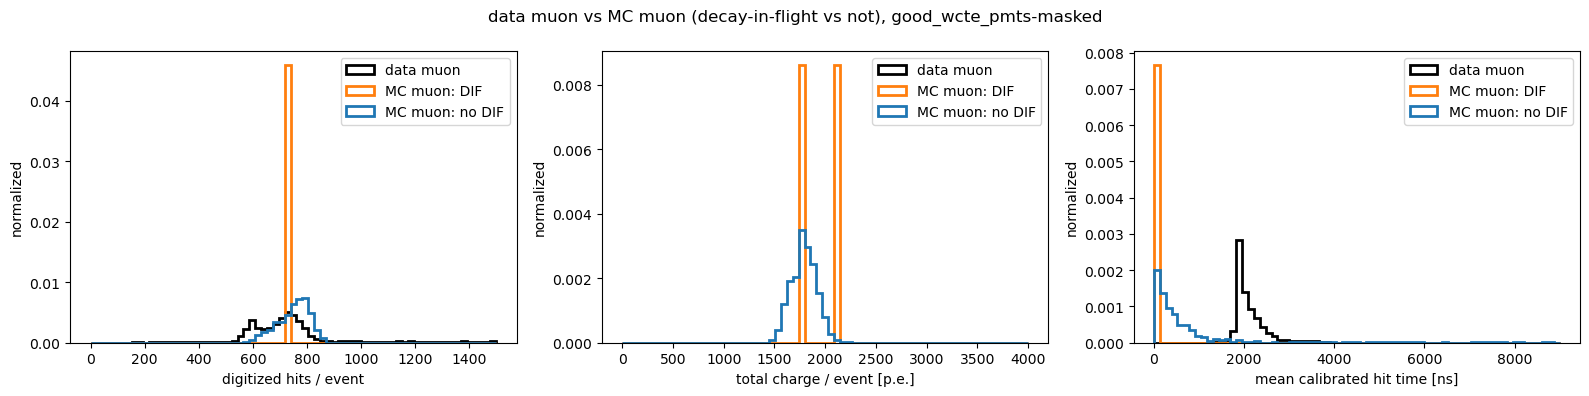

In [11]:
samples = [
    (f"data {PARTICLE}",         data_hits_masked,      "k"),
    (f"MC {PARTICLE}: DIF",      sim_dif_hits_masked,   "C1"),
    (f"MC {PARTICLE}: no DIF",   sim_nodif_hits_masked, "C0"),
]

data_hits_masked["q_pe"] = data_hits_masked["q"] / 143  # convert to p.e. for plotting

def per_event(hits, how):
    n = ak.num(hits["q"])
    if how == "nhits":
        return ak.to_numpy(n)
    if how == "totq":
        return ak.to_numpy(ak.sum(hits["q"], axis=1))
    if how == "meant":
        return ak.to_numpy(ak.mean(hits["t"], axis=1)[n > 0])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, how, xlabel, bins in [
    (axes[0], "nhits", "digitized hits / event",       np.linspace(0, 1500, 70)),
    (axes[1], "totq",  "total charge / event [p.e.]",  np.linspace(0, 4000, 70)),
    (axes[2], "meant", "mean calibrated hit time [ns]", np.linspace(0, 9000, 70)),
]:
    for label, hits, color in samples:
        ax.hist(per_event(hits, how), bins=bins, density=True, histtype="step",
                lw=2, color=color, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("normalized")
    ax.legend()

fig.suptitle(f"data {PARTICLE} vs MC {PARTICLE} (decay-in-flight vs not), good_wcte_pmts-masked")
fig.tight_layout()


<cell_type>markdown</cell_type>## 5. Per-event truth summary for the simulated `PARTICLE` sample

Classify each simulated `PARTICLE` event by its ultimate fate (`stop_process` /
`had_inelastic` / `had_elastic` / `true_exit_ke`) and flag the decay-in-flight
subset. This is the table behind the decay-in-flight vs not split used everywhere below.


In [12]:
def classify_outcome(stop_process, had_inelastic, had_elastic, true_exit_ke):
    """Human-readable summary of what happened to the primary, from MC truth."""
    if "Decay" in stop_process:
        return "decayed in flight"
    if "CaptureAtRest" in stop_process:
        return "captured at rest"
    if had_inelastic:
        return "hadronic inelastic interaction"
    if had_elastic:
        return "hadronic elastic scatter"
    if true_exit_ke >= 0:
        return "exited the tank"
    return "ranged out (ionization only)"

outcomes = [
    classify_outcome(sp, hi, he, ke)
    for sp, hi, he, ke in zip(
        ak.to_list(sim_species["stop_process"]), ak.to_list(sim_species["had_inelastic"]),
        ak.to_list(sim_species["had_elastic"]), ak.to_list(sim_species["true_exit_ke"]),
    )
]

track_summary = pd.DataFrame({
    "event_number":       ak.to_numpy(sim_species["event_number"]),
    "true_pdg":           ak.to_numpy(sim_species["true_pdg"]),
    "true_E_MeV":         ak.to_numpy(sim_species["true_E"]),
    "n_tracks":           ak.to_numpy(ak.num(sim_species["track_id"])),
    "n_prim_daughters":   ak.to_numpy(sim_species["n_prim_daughters"]),
    "n_elastic":          ak.to_numpy(sim_species["n_elastic"]),
    "n_inelastic":        ak.to_numpy(sim_species["n_inelastic"]),
    "stop_process":       ak.to_list(sim_species["stop_process"]),
    "decayed_in_flight":  [o == "decayed in flight" for o in outcomes],
    "outcome":            outcomes,
})

print(track_summary["outcome"].value_counts())
track_summary.head(10)


outcome
captured at rest     998
decayed in flight      2
Name: count, dtype: int64


,event_number,true_pdg,true_E_MeV,n_tracks,n_prim_daughters,n_elastic,n_inelastic,stop_process,decayed_in_flight,outcome
0,0,13,455.658386,74,43,0,0,muMinusCaptureAtRest,False,captured at rest
1,1,13,455.658386,83,37,0,0,muMinusCaptureAtRest,False,captured at rest
2,2,13,455.658386,112,39,0,0,muMinusCaptureAtRest,False,captured at rest
3,3,13,455.658386,110,40,0,0,muMinusCaptureAtRest,False,captured at rest
4,4,13,455.658386,127,34,0,0,muMinusCaptureAtRest,False,captured at rest
5,5,13,455.658386,141,35,0,0,muMinusCaptureAtRest,False,captured at rest
6,6,13,455.658386,132,38,0,0,muMinusCaptureAtRest,False,captured at rest
7,7,13,455.658386,56,38,0,0,muMinusCaptureAtRest,False,captured at rest
8,8,13,455.658386,67,35,0,0,muMinusCaptureAtRest,False,captured at rest
9,9,13,455.658386,137,49,0,0,muMinusCaptureAtRest,False,captured at rest


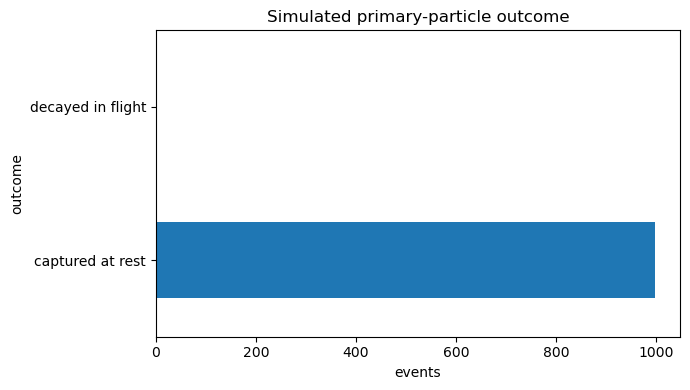

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
track_summary["outcome"].value_counts().plot.barh(ax=ax)
ax.set_xlabel("events")
ax.set_title("Simulated primary-particle outcome")
fig.tight_layout()


<cell_type>markdown</cell_type>## 6. Characterise the decay-in-flight `PARTICLE` sample

For every `PARTICLE` that decayed in flight, find its primary track inside `track_*`
(matched by start position) and its decay daughter (`|pdg| == DECAY_DAUGHTER_PDG[PARTICLE]`,
parent == primary, creator process `Decay` - e.g. muon daughter for a decaying pion,
electron daughter for a decaying muon). From those, derive:

* **decay path length** - distance from the primary's start to the decay point (= daughter start)
* **decay position along the beam** (z, WCTE frame)
* **daughter initial KE** - how much energy the decay daughter carries into the water

and compare the light yield (masked hits/event) of the decay-in-flight vs
non-decay sample against the data sample.


2 / 2 decay-in-flight muon events with an identified decay daughter (|pdg|=11)
  decay path length : mean 151.3 cm, median 151.3 cm
  daughter KE        : mean 52.8 MeV, median 52.8 MeV


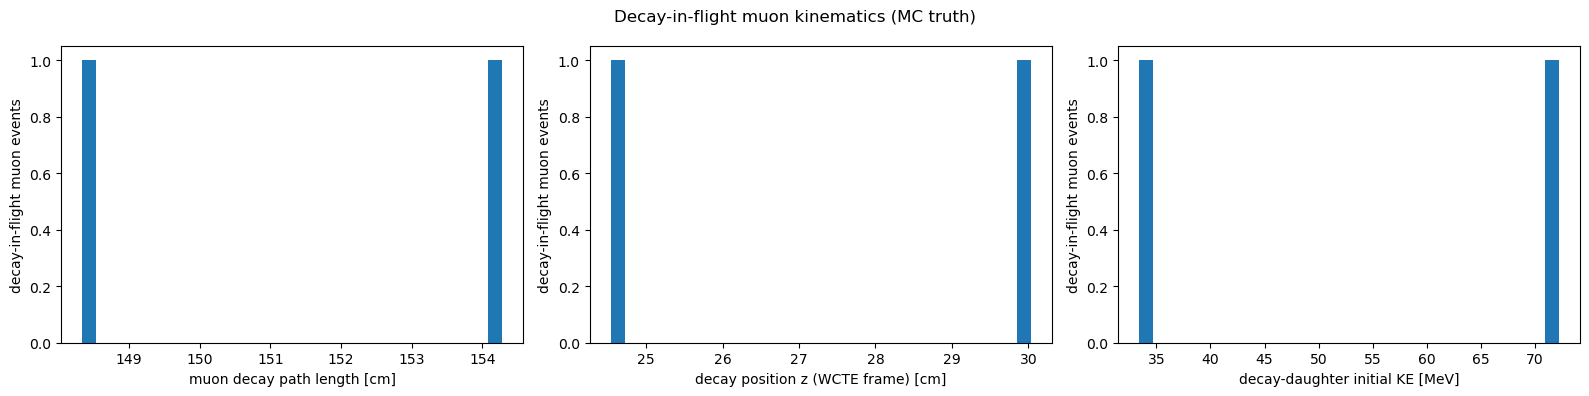

In [14]:
def find_primary_index(ev):
    """Index into ev.track_* of the primary track (matched by start position)."""
    matches = np.flatnonzero(
        (np.asarray(ev["track_start_x"]) == ev["true_start_x"]) &
        (np.asarray(ev["track_start_y"]) == ev["true_start_y"]) &
        (np.asarray(ev["track_start_z"]) == ev["true_start_z"])
    )
    return int(matches[0]) if len(matches) else None

decay_daughter_pdg = DECAY_DAUGHTER_PDG.get(PARTICLE)
if decay_daughter_pdg is None:
    raise ValueError(f"no decay-daughter PDG defined for PARTICLE={PARTICLE!r} - add one to DECAY_DAUGHTER_PDG")

def decay_info(ev):
    """(path_len_cm, decay_z_cm, daughter_ke_MeV) for a decay-in-flight primary, else None."""
    pi = find_primary_index(ev)
    if pi is None:
        return None
    prim_id = ev["track_id"][pi]
    for j in range(len(ev["track_id"])):
        if (ev["track_parent_id"][j] == prim_id and abs(ev["track_pdg"][j]) == decay_daughter_pdg
                and ev["track_process"][j] == "Decay"):
            dx = ev["track_start_x"][j] - ev["true_start_x"]
            dy = ev["track_start_y"][j] - ev["true_start_y"]
            dz = ev["track_start_z"][j] - ev["true_start_z"]
            return (float(np.sqrt(dx*dx + dy*dy + dz*dz)),
                    float(ev["track_start_z"][j]),
                    float(ev["track_ke"][j]))
    return None

dif_rows = [info for ev in sim_dif if (info := decay_info(ev)) is not None]
path_len  = np.array([r[0] for r in dif_rows])
decay_z   = np.array([r[1] for r in dif_rows])
daughter_ke = np.array([r[2] for r in dif_rows])

print(f"{len(dif_rows)} / {len(sim_dif)} decay-in-flight {PARTICLE} events with an identified decay daughter "
      f"(|pdg|={decay_daughter_pdg})")
if len(dif_rows):
    print(f"  decay path length : mean {path_len.mean():.1f} cm, median {np.median(path_len):.1f} cm")
    print(f"  daughter KE        : mean {daughter_ke.mean():.1f} MeV, median {np.median(daughter_ke):.1f} MeV")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(path_len, bins=30); axes[0].set_xlabel(f"{PARTICLE} decay path length [cm]")
    axes[1].hist(decay_z,  bins=30); axes[1].set_xlabel("decay position z (WCTE frame) [cm]")
    axes[2].hist(daughter_ke, bins=30); axes[2].set_xlabel("decay-daughter initial KE [MeV]")
    for ax in axes:
        ax.set_ylabel(f"decay-in-flight {PARTICLE} events")
    fig.suptitle(f"Decay-in-flight {PARTICLE} kinematics (MC truth)")
    fig.tight_layout()
else:
    print("  (nothing to plot - no decay-in-flight events in this sample)")


<cell_type>markdown</cell_type>## 7. Side-by-side event display: data `PARTICLE` vs simulated decay-in-flight `PARTICLE`

Uses `WCTE_event_display` (https://github.com/cookl/WCTE_event_display), a standalone
2D "unrolled cylinder" display keyed on `(mPMT slot, PMT position)` channels - exactly
the convention `hit_mpmt_slot_ids` / `hit_pmt_position_ids` already use on both the
data and (post-`flatten_wcsim.C`-update) simulation side, so no tube-number mapping
step is needed for either file. The simulated event is one where the primary decayed
in flight; its hits are colored by which track produced them, so the primary segment
and the decay-daughter segment show up as different colors.


In [15]:
sys.path.insert(0, EVENT_DISPLAY_DIR)
from EventDisplay import EventDisplay  # noqa: E402
import os
os.chdir(EVENT_DISPLAY_DIR)  # load_mPMT_positions resolves its CSV relative to the module dir

ed = EventDisplay()
ed.load_mPMT_positions("mPMT_2D_projection_angles.csv")


In [16]:
def channel_first_value(slots, positions, values, n_channels):
    """One representative value per (slot, position) channel - the first hit seen.

    Unlike EventDisplay.process_data (sum, or min with a 0-vs-unset ambiguity), this
    is what we want for a *categorical* value like a track id: pick a single
    representative hit per channel rather than summing/averaging track ids.
    """
    out = np.full(n_channels, np.nan)
    for slot, pos, v in zip(slots, positions, values):
        ch = 19 * int(slot) + int(pos)
        if np.isnan(out[ch]):
            out[ch] = v
    return out

def classify_mpmt_slots(good_encoded, n_mpmts=106, n_pos=19):
    """Classify each mPMT slot by how many of its 19 positions are in the
    good_wcte_pmts whitelist (slot*100+position encoding).

    Returns (fully_off_slots, partially_off_slots): slots with 0/19 good
    channels, and slots with some-but-not-all good channels, respectively.
    Fully-good slots (19/19) are not returned - nothing to highlight there.
    """
    good_set = set(int(v) for v in good_encoded)
    fully_off, partially_off = [], []
    for slot in range(n_mpmts):
        n_good = sum((slot * 100 + pos) in good_set for pos in range(n_pos))
        if n_good == 0:
            fully_off.append(slot)
        elif n_good < n_pos:
            partially_off.append(slot)
    return np.array(fully_off), np.array(partially_off)

def draw_event(ax, ed, data, cmap, norm, title, color_label=None,
                fully_off_slots=(), partially_off_slots=()):
    """Minimal reimplementation of EventDisplay.plotEventDisplay that draws into a
    given ax instead of creating its own figure, so two events can share one row.

    fully_off_slots / partially_off_slots (mPMT slot IDs, see classify_mpmt_slots)
    are drawn as extra highlighted circles on top of the normal per-mPMT outline,
    so it's visually obvious which blank regions are due to the good_wcte_pmts
    mask rather than just this one event happening to have no hits there.
    """
    import copy
    from matplotlib.patches import Circle
    from matplotlib.collections import PatchCollection

    coordinates = ed.coordinates_eachChannel()
    plot_data = data.copy()
    #plot_data[plot_data == 0] = np.nan  # keep unhit channels blank, as plotEventDisplay does

    cmap = copy.copy(cmap)
    cmap.set_bad(color="white")

    pmt_circles = [Circle((x, y), radius=0.48) for x, y in ed.mPMT_2D_projection[:, 1:3]]
    ax.add_collection(PatchCollection(pmt_circles, facecolor="none", linewidths=1, edgecolors="0.85"))
    pts = ax.scatter(coordinates[:, 0], coordinates[:, 1], c=plot_data, s=25, cmap=cmap, norm=norm)

    # highlight mPMTs excluded (fully or partially) by the good_wcte_pmts mask
    if len(fully_off_slots):
        xy = ed.mPMT_2D_projection[np.asarray(fully_off_slots), 1:3]
        ax.add_collection(PatchCollection(
            [Circle((x, y), radius=0.75) for x, y in xy],
            facecolor="none", edgecolors="red", linewidths=2, zorder=5))
    if len(partially_off_slots):
        xy = ed.mPMT_2D_projection[np.asarray(partially_off_slots), 1:3]
        ax.add_collection(PatchCollection(
            [Circle((x, y), radius=0.75) for x, y in xy],
            facecolor="none", edgecolors="orange", linewidths=2, linestyles="--", zorder=5))

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.colorbar(pts, ax=ax, pad=0.01, label=color_label)
    return pts


In [17]:
# --- classify which mPMT slots the good_wcte_pmts mask excludes (once, reused below) ---
fully_off_slots, partially_off_slots = classify_mpmt_slots(good_wcte_pmts)
print(f"{len(fully_off_slots)} mPMT slots fully off, {len(partially_off_slots)} partially off "
      f"(good_wcte_pmts covers {len(good_wcte_pmts)}/{106*19} channels)")


23 mPMT slots fully off, 12 partially off (good_wcte_pmts covers 1562/2014 channels)


[1, 1, 1, 1, 1, 92650, 1, 1, 1, 1, 1, 1, ..., 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


NameError: name 'sim_hit_tids' is not defined

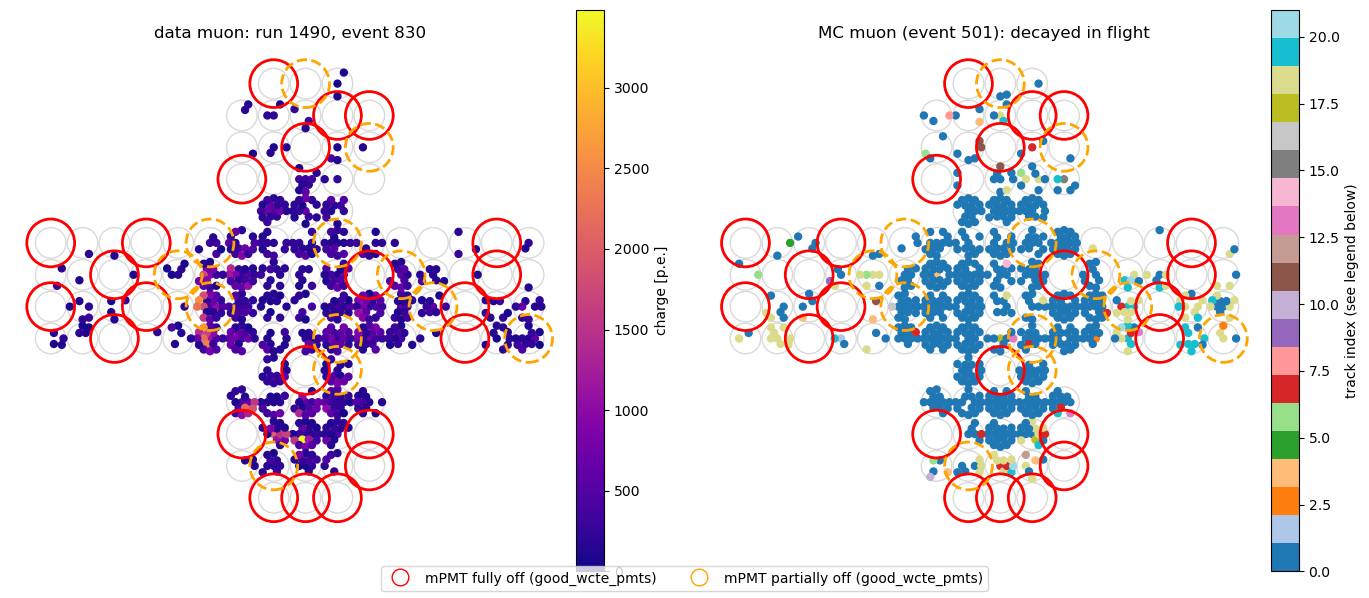

In [18]:
# --- pick one data event and one simulated decay-in-flight event to compare ---
# NOTE: plot the good_wcte_pmts-MASKED hits (data_hits_masked / sim_hits_masked from
# section 3), not the raw data/sim events - otherwise the two panels aren't actually
# looking at the same set of live channels.
data_event_idx = 10
sim_event_idx  = 501 #int(np.flatnonzero(dif_mask)[0]) if dif_mask.any() else 34

#501, 378

data_ev, data_ev_hits = data[data_event_idx], data_hits_masked[data_event_idx]
sim_ev,  sim_ev_hits  = sim[sim_event_idx],   sim_hits_masked[sim_event_idx]

#sim_hit_tids   = ak.to_list(sim_ev_hits["hit_track_id"])
#hits_per_track = Counter(sim_hit_tids)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- left: real data event, colored by charge ---
data_channel_q = channel_first_value(
    ak.to_list(data_ev_hits["slot"]), ak.to_list(data_ev_hits["pos"]),
    ak.to_list(data_ev_hits["q"]), ed.nChannels,
)
draw_event(
    axes[0], ed, data_channel_q, cmap=plt.cm.plasma,
    norm=mcolors.Normalize(vmin=0, vmax=np.nanmax(data_channel_q) if np.any(~np.isnan(data_channel_q)) else 1),
    title=f"data {PARTICLE}: run {int(data_ev['run_id'])}, event {int(data_ev['event_number'])}",
    color_label="charge [p.e.]",
    fully_off_slots=fully_off_slots, partially_off_slots=partially_off_slots,
)

# --- right: simulated decay-in-flight event, colored by parent TRACK ID (not charge) ---
print(sim_ev_hits["hit_track_id"])
track_ids_in_event = sorted(set(ak.to_list(sim_ev_hits["hit_track_id"])))
track_id_to_color_index = {tid: i for i, tid in enumerate(track_ids_in_event)}
hit_color_index = [track_id_to_color_index[tid] for tid in ak.to_list(sim_ev_hits["hit_track_id"])]

sim_channel_track = channel_first_value(
    ak.to_list(sim_ev_hits["slot"]), ak.to_list(sim_ev_hits["pos"]),
    hit_color_index, ed.nChannels,
)
draw_event(
    axes[1], ed, sim_channel_track, cmap=plt.cm.tab20,
    norm=mcolors.Normalize(vmin=0, vmax=max(len(track_ids_in_event) - 1, 1)),
    title=f"MC {PARTICLE} (event {int(sim_ev['event_number'])}): {classify_outcome(str(sim_ev['stop_process']), sim_ev['had_inelastic'], sim_ev['had_elastic'], sim_ev['true_exit_ke'])}",
    color_label="track index (see legend below)",
    fully_off_slots=fully_off_slots, partially_off_slots=partially_off_slots,
)

# proxy legend entries for the red/orange highlight circles (PatchCollections don't auto-legend)
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker="o", color="red", markerfacecolor="none", linestyle="", markersize=12, label="mPMT fully off (good_wcte_pmts)"),
    Line2D([0], [0], marker="o", color="orange", markerfacecolor="none", linestyle="", markersize=12, label="mPMT partially off (good_wcte_pmts)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2)
fig.tight_layout()

hits_per_track = Counter(sim_hit_tids)

# legend: which track index corresponds to which particle
print("Track color legend for the simulated event:")
for tid, idx in track_id_to_color_index.items():
    matches = np.flatnonzero(np.asarray(sim_ev["track_id"]) == tid)
    n = hits_per_track[tid]
    #print(matches)
    if len(matches):
        j = matches[0]
        tag = " <- PRIMARY" if tid == sim_ev["track_id"][find_primary_index(sim_ev)] else ""
        print(f"  color {idx}: track_id={tid}  pdg={sim_ev['track_pdg'][j]}  "
              f"process={sim_ev['track_process'][j]}  ke={sim_ev['track_ke'][j]:.2f} MeV  ({n} hits){tag}")
    else:
        print(f"  color {idx}: track_id={tid}  (dark noise / not in truth track list)" if tid == -1
              else f"  color {idx}: track_id={tid}  (no truth match)")


### 7b. Same display, MC side restricted to tracks with > 20 hits

Re-draw the pair, but colour the simulated hits only for tracks that produced
**more than 20 digitized hits** in this event (`good_wcte_pmts`-masked). Hits from
minor tracks (dark noise, low-energy deltas, small showers) are left blank so the
few tracks carrying the bulk of the light stand out. The threshold and the blanking
are noted in the figure legend.


Track colour legend (only tracks with > 20 digitized hits in this event):
  color 0: track_id=1  pdg=13  process=initial  ke=350.00 MeV  (575 hits) <- PRIMARY
  color 1: track_id=92650  pdg=11  process=Decay  ke=33.40 MeV  (69 hits)
  color 2: track_id=99145  pdg=11  process=compt  ke=10.87 MeV  (24 hits)


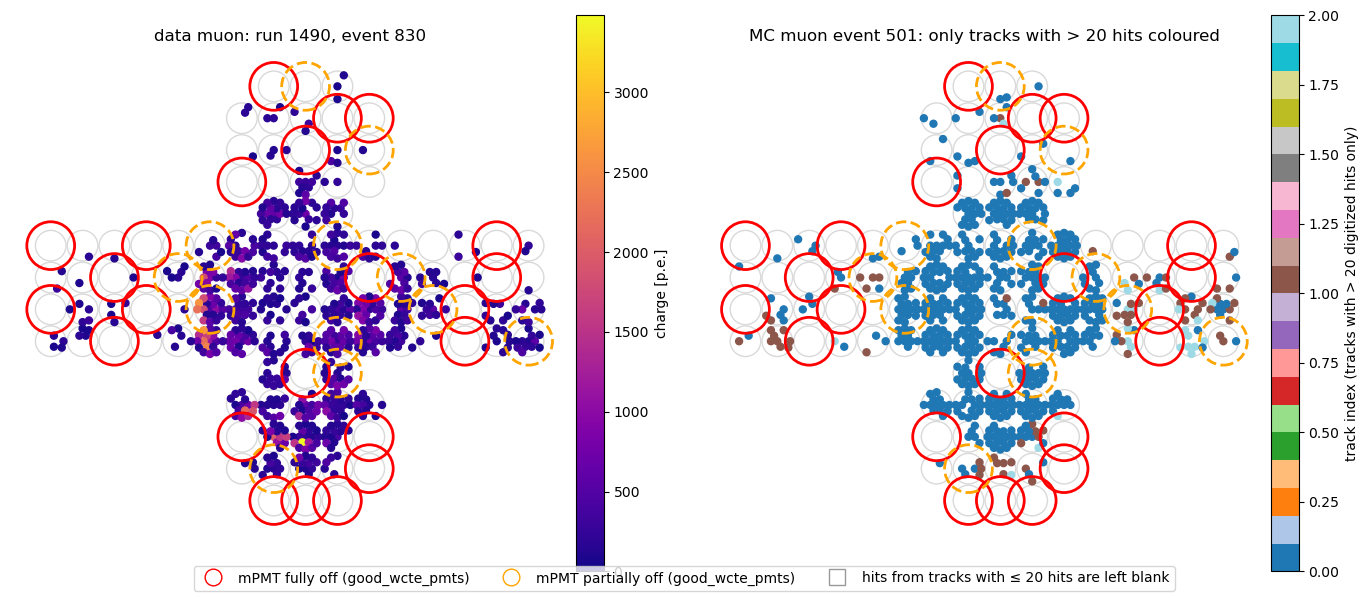

In [ ]:
# --- same event display, but on the MC side colour ONLY the tracks that produced
#     more than MIN_HITS digitized hits in this event (good_wcte_pmts-masked hits).
#     Every other track's hits are left blank/white. The data panel is unchanged. ---
MIN_HITS = 20

sim_hit_tids   = ak.to_list(sim_ev_hits["hit_track_id"])
hits_per_track = Counter(sim_hit_tids)
major_tids     = sorted(t for t, c in hits_per_track.items() if c > MIN_HITS)
major_color_index = {tid: i for i, tid in enumerate(major_tids)}

# major track -> its colour index; every other track -> NaN (drawn blank)
hit_color_index_major = [major_color_index.get(tid, np.nan) for tid in sim_hit_tids]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: identical data event to the plot above
draw_event(
    axes[0], ed, data_channel_q, cmap=plt.cm.plasma,
    norm=mcolors.Normalize(vmin=0, vmax=np.nanmax(data_channel_q) if np.any(~np.isnan(data_channel_q)) else 1),
    title=f"data {PARTICLE}: run {int(data_ev['run_id'])}, event {int(data_ev['event_number'])}",
    color_label="charge [p.e.]",
    fully_off_slots=fully_off_slots, partially_off_slots=partially_off_slots,
)

# right: simulated event, only tracks with > MIN_HITS hits coloured
sim_channel_track_major = channel_first_value(
    ak.to_list(sim_ev_hits["slot"]), ak.to_list(sim_ev_hits["pos"]),
    hit_color_index_major, ed.nChannels,
)
draw_event(
    axes[1], ed, sim_channel_track_major, cmap=plt.cm.tab20,
    norm=mcolors.Normalize(vmin=0, vmax=max(len(major_tids) - 1, 1)),
    title=f"MC {PARTICLE} event {int(sim_ev['event_number'])}: only tracks with > {MIN_HITS} hits coloured",
    color_label=f"track index (tracks with > {MIN_HITS} digitized hits only)",
    fully_off_slots=fully_off_slots, partially_off_slots=partially_off_slots,
)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker="o", color="red",    markerfacecolor="none", linestyle="", markersize=12, label="mPMT fully off (good_wcte_pmts)"),
    Line2D([0], [0], marker="o", color="orange", markerfacecolor="none", linestyle="", markersize=12, label="mPMT partially off (good_wcte_pmts)"),
    Line2D([0], [0], marker="s", color="none",   markerfacecolor="white", markeredgecolor="0.6", linestyle="", markersize=12, label=f"hits from tracks with ≤ {MIN_HITS} hits are left blank"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3)
fig.tight_layout()

print(f"Track colour legend (only tracks with > {MIN_HITS} digitized hits in this event):")
for tid, idx in major_color_index.items():
    n = hits_per_track[tid]
    matches = np.flatnonzero(np.asarray(sim_ev["track_id"]) == tid)
    if len(matches):
        j = matches[0]
        tag = " <- PRIMARY" if tid == sim_ev["track_id"][find_primary_index(sim_ev)] else ""
        print(f"  color {idx}: track_id={tid}  pdg={sim_ev['track_pdg'][j]}  "
              f"process={sim_ev['track_process'][j]}  ke={sim_ev['track_ke'][j]:.2f} MeV  ({n} hits){tag}")
    else:
        print(f"  color {idx}: track_id={tid}  ({n} hits)  "
              + ("(dark noise)" if tid == -1 else "(no truth match)"))
